# Avery's Pre-merge Workspace

In [134]:
#Basics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#FeatureSelection
from sklearn.feature_selection import SelectFromModel # For feature selection via L1 and/or L2
from sklearn.linear_model import LassoCV
from sklearn import svm

#Addressing class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#XGB
import xgboost as xgb
from xgboost import plot_tree # Interpretability feature
from xgboost import plot_importance

#Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, auc, roc_curve

#Interpretability
import shap #Explainer

#Optimization
import optuna

# File systems
import os
import string

## Function Definitions

These functions, respectively:

*   `scatter_matrix_ex`: Generates a scatter matrix plot for numerical columns in a DataFrame.
*   `corr_matrix_ex`: Generates a heatmap of the correlation matrix for numerical columns in a DataFrame.
*   `givendf_investigation`: Investigates a given DataFrame by plotting count plots for categorical columns and histograms for numerical columns.
*   `confusion_matrix_ex`: Displays a confusion matrix for classification model evaluation.
*   `roc_curve_display_ex`: Displays a Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC) for classification model evaluation.

In [135]:
def scatter_matrix_ex(numeric_df, custom_alpha=0.05):
  axs = pd.plotting.scatter_matrix(numeric_df, figsize=(30,16), alpha=custom_alpha, diagonal='kde')

  numeric_n = len(numeric_df.columns)
  for x in range(numeric_n):
      for y in range(numeric_n):
          ax = axs[x, y]
          ax.xaxis.label.set_rotation(90)
          ax.yaxis.label.set_rotation(0)
          ax.yaxis.labelpad = 50
          ax.xaxis.label.set_fontsize(10)
          ax.yaxis.label.set_fontsize(10)
  plt.show()

def corr_matrix_ex(numeric_df, df_name = 'Given Dataframe'):
  data_corrmat = numeric_df.corr()
  plt.figure(figsize=(30, 16))
  plt.title(f"Correlation Matrix for {df_name}")
  sns.heatmap(data_corrmat,
              cmap='coolwarm',
              fmt='.2f',
              annot=True,
              vmin = -1,
              vmax = 1,
              annot_kws={"size": 10})
  plt.tight_layout()
  plt.show()

def givendf_investigation(given_df):
  given_numerics = given_df.select_dtypes(include=[np.number]).columns.tolist()
  given_categoricals = given_df.select_dtypes(include=['object','category']).columns.tolist()

  if len(given_categoricals) % 2 == 0:
    given_rows = len(given_categoricals) // 2
  else:
    given_rows = (len(given_categoricals) // 2) + 1

  fig, axes = plt.subplots(given_rows, 2, figsize=(14, given_rows * 4))
  for i_cat, cat_num in zip( given_categoricals, range(len(given_categoricals)) ):
    row_idx = cat_num // 2
    col_idx = cat_num % 2
    sns.countplot(data = given_df, x=i_cat, ax=axes[row_idx, col_idx], stat="percent")
    axes[row_idx, col_idx].set_xlabel('')
    axes[row_idx, col_idx].set_ylabel(f"% by {i_cat}") # Set y-label to the actual column name
  plt.tight_layout()
  plt.show()

  if len(given_numerics) % 3 == 0:
    given_rows = len(given_numerics) // 3
  elif len(given_numerics) < 3:
    given_rows = 1
  else:
    given_rows = (len(given_numerics) // 3) + 1


  if given_rows == 1:
    fig, axes = plt.subplots(1, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[col_idx], element="step")
      axes[col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[col_idx].set_xlabel('')
      axes[col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[col_idx].legend()

  else:
    fig, axes = plt.subplots(given_rows, 3, figsize=(14, given_rows * 4))
    for i_cat, cat_num in zip(given_numerics, range(len(given_numerics)) ):
      row_idx = cat_num // 3
      col_idx = cat_num % 3
      sns.histplot(data = given_df, x=i_cat, alpha=0.5, ax=axes[row_idx, col_idx], element="step")
      axes[row_idx, col_idx].axvline(np.mean(data[i_cat]), color='red', linestyle='--', label='Population Mean', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].axvline(np.median(data[i_cat]), color='black', linestyle='--', label='Population Median', linewidth=0.8, alpha = 0.6)
      axes[row_idx, col_idx].set_xlabel('')
      axes[row_idx, col_idx].set_ylabel(f"Count of Value of {i_cat}") # Set y-label to the actual column name

      if col_idx % 3 == 1:
        axes[row_idx, col_idx].legend()


  plt.tight_layout()
  plt.show()

def confusion_matrix_ex(y_test, y_pred, y_labels=['Positive','Negative'], y_topic = 'Topic'):
  y_matrix = confusion_matrix(y_test, y_pred)
  y_accuracy = accuracy_score(y_test, y_pred)
  cm = ConfusionMatrixDisplay(confusion_matrix = y_matrix, display_labels=y_labels)
  cm.plot(cmap='Blues')
  plt.suptitle(f'{y_topic} Confusion Matrix', weight=800)
  plt.title(f'Accuracy: {y_accuracy:.3f}')
  plt.show()

def roc_curve_display_ex(esti_provided, X_provided, y_provided, y_topic = 'Topic'):
  rcd = RocCurveDisplay.from_estimator(esti_provided,
                                       X_provided,
                                       y_provided,
                                         plot_chance_level = True)
  plt.fill_between(rcd.fpr, rcd.tpr, rcd.fpr, where=rcd.tpr>rcd.fpr, interpolate=True,  alpha=0.4)
  plt.suptitle(f'{y_topic} ROC-AUC Curve', weight=800)
  plt.title(f'ROC-AUC: {rcd.roc_auc:.3f}')
  plt.show()

def perf_output(g_model, set_X, set_y, mname = "Model"):
  # Evaluate on test set
  y_pred = g_model.predict(set_X)
  y_probs = g_model.predict_proba(set_X)[:, 1]

  # get accuracy score
  test_accuracy = accuracy_score(set_y, y_pred)
  print(f"{mname} Accuracy:", test_accuracy)

  # get auc score
  test_auc = roc_auc_score(set_y, y_probs)
  print(f"{mname} ROC-AUC:", test_auc)

  # Classification report
  print("\nClassification Report:\n", classification_report(set_y, y_pred))

  roc_curve_display_ex(g_model, set_X, set_y, y_topic = mname)

In [136]:
# Index of all columns within the original dataset, pre-trimming

CES2024_COLUMNS = {
    # ── Identifiers & Weights ──
    "caseid": "Case ID",
    "tookpost": "Took post-election survey",
    "commonweight": "Common content weight (all respondents, adults)",
    "commonpostweight": "Common content post-election weight (both waves, adults)",
    "vvweight": "Vote validation weight (matched to registration, registered adults)",
    "vvweight_post": "Vote validation post weight (both waves & matched, registered adults)",

    # ── Consent & Address ──
    "CCEStake": "Consent to participate",
    "add_confirm": "Confirm address",
    "inputzip": "Input zip code",

    # ── Demographics ──
    "birthyr": "Birth Year",                    # Age = 2024 - birthyr
    "gender4": "Gender",
    "gender4_t": "Gender (text)",
    "educ": "Education",                        # (Include in naive model)
    "race": "Race",
    "race_other": "Race - Other (text)",        # DROP
    "hispanic": "Hispanic",

    # ── Multiracial (check all) ──
    "multrace_1": "Multiracial - White",
    "multrace_2": "Multiracial - Black",
    "multrace_3": "Multiracial - Hispanic",
    "multrace_4": "Multiracial - Asian",
    "multrace_5": "Multiracial - Native American",
    "multrace_8": "Multiracial - Middle Eastern",
    "multrace_97": "Multiracial - Other",
    "multrace_98": "Multiracial - Don't know",

    # ── Device & Registration ──
    "comptype": "Device type",
    "votereg": "Voter Registration Status",
    "votereg_f": "Registered to vote (zip confirmation)",
    "regzip": "Registered zip code",

    # ── Party ID ──
    "pid3": "3 point party ID",
    "pid3_t": "3 point party ID (text)",
    "pid7": "7 point Party ID",

    # ── Geography ──
    "inputstate": "State of Residence",
    "region": "Region",
    "ccesmodule": "Team module assigned",

    # ── Media use past 24 hrs (check all) ──
    "CC24_300_1": "Media use past 24 hrs - Used social media",
    "CC24_300_2": "Media use past 24 hrs - Watched TV news",
    "CC24_300_3": "Media use past 24 hrs - Read a newspaper",
    "CC24_300_4": "Media use past 24 hrs - Listened to radio news",
    "CC24_300_5": "Media use past 24 hrs - None of these",

    # ── Media use follow-ups ──
    "CC24_300a": "Media use - TV news type",
    "CC24_300c": "Media use - Newspaper type",

    # ── Media use networks (check all) ──
    "CC24_300b_1": "Media networks - ABC",
    "CC24_300b_2": "Media networks - CBS",
    "CC24_300b_3": "Media networks - NBC",
    "CC24_300b_4": "Media networks - CNN",
    "CC24_300b_5": "Media networks - Fox News",
    "CC24_300b_6": "Media networks - MSNBC",
    "CC24_300b_7": "Media networks - PBS",
    "CC24_300b_8": "Media networks - Other",

    # ── Recent social media use (check all) ──
    "CC24_300d_1": "Recent social media use - Posted a story, photo, video or link about politics",
    "CC24_300d_2": "Recent social media use - Posted a comment about politics",
    "CC24_300d_3": "Recent social media use - Read a story or watched a video about politics",
    "CC24_300d_4": "Recent social media use - Followed a political event",
    "CC24_300d_5": "Recent social media use - Forwarded a story, photo, video or link about politics to friends",
    "CC24_300d_6": "Recent social media use - None of the above",

    # ── Economic perceptions ──
    "CC24_301": "National Economics",
    "CC24_302": "Household income change",
    "CC24_303": "Price change in past year",

    # ── Life Changes (check all) ──
    "CC24_305_1": "Life Changes - Married",
    "CC24_305_2": "Life Changes - Lost a job",
    "CC24_305_3": "Life Changes - Finished school",
    "CC24_305_4": "Life Changes - Retired",
    "CC24_305_5": "Life Changes - Divorced",
    "CC24_305_6": "Life Changes - Had a child",
    "CC24_305_7": "Life Changes - Taken a new job",
    "CC24_305_9": "Life Changes - Been a victim of a crime",
    "CC24_305_10": "Life Changes - Visited an emergency room",
    "CC24_305_11": "Life Changes - Visited a doctor for a regular examination",
    "CC24_305_12": "Life Changes - Received a raise at work",
    "CC24_305_13": "Life Changes - Had a pay cut at work",
    "CC24_305_14": "Life Changes - None of the above",

    # ── Health ──
    "CC24_309e": "General health",

    # ── Ukraine (check all) ──
    "CC24_308a_1": "Ukraine - Do not get involved",
    "CC24_308a_2": "Ukraine - Send food, medicine, and other humanitarian aid to Ukraine",
    "CC24_308a_3": "Ukraine - Impose economic sanctions on Russia",
    "CC24_308a_4": "Ukraine - Provide arms to Ukraine",
    "CC24_308a_5": "Ukraine - Send military support staff to Ukraine (non-combat)",
    "CC24_308a_6": "Ukraine - Send significant force to fight Russia",
    "CC24_308a_7": "Ukraine - Negotiate a peace accord between Russia and Ukraine",
    "CC24_308a_8": "Ukraine - Send aid to affected communities after the conflict to help rebuild",

    # ── Israel/Gaza (check all) ──
    "CC24_308b_1": "Israel/Gaza - Do not get involved",
    "CC24_308b_2": "Israel/Gaza - Send food, medicine and other aid to the communities affected",
    "CC24_308b_3": "Israel/Gaza - Provide arms to Israel",
    "CC24_308b_4": "Israel/Gaza - Provide arms to Hamas",
    "CC24_308b_5": "Israel/Gaza - Send the US Navy and troops to the region",
    "CC24_308b_6": "Israel/Gaza - Send military support staff (non-combat) to Israel",
    "CC24_308b_7": "Israel/Gaza - Send military support staff (non-combat) to Gaza",
    "CC24_308b_8": "Israel/Gaza - Negotiate a peace settlement",
    "CC24_308b_9": "Israel/Gaza - Send aid to affected communities after the conflict",

    # ── Emergency expense (check all) ──
    "CC24_309d_1": "Emergency expense - Put it on credit card, pay off in full",
    "CC24_309d_2": "Emergency expense - Put it on credit card, pay off over time",
    "CC24_309d_3": "Emergency expense - With checking/savings or cash",
    "CC24_309d_4": "Emergency expense - Bank loan or line of credit",
    "CC24_309d_5": "Emergency expense - Borrowing from friend or family",
    "CC24_309d_6": "Emergency expense - Payday loan, deposit advance, or overdraft",
    "CC24_309d_7": "Emergency expense - By selling something",
    "CC24_309d_8": "Emergency expense - Wouldn't be able to pay right now",
    "CC24_309d_9": "Emergency expense - Other",
    "CC24_309d_t": "Emergency expense - Other (text)",

    # ── Know Party in Government (grid) ──
    "CC24_310a": "Know Party in Government - U.S. House of Representatives",
    "CC24_310b": "Know Party in Government - U.S. Senate",
    "CC24_310c": "Know Party in Government - State Senate",
    "CC24_310d": "Know Party in Government - State Lower Chamber",

    # ── Know Party of Representative (grid) ──
    "CC24_311a": "Know Party of Representative - Governor",
    "CC24_311b": "Know Party of Representative - Senator 1",
    "CC24_311c": "Know Party of Representative - Senator 2",
    "CC24_311d": "Know Party of Representative - U.S. House member",

    # ── Job Approval Institutions (grid) ──
    "CC24_312a": "Job Approval - President Biden",
    "CC24_312i": "Job Approval - Vice President Harris",
    "CC24_312b": "Job Approval - U.S. Congress",
    "CC24_312c": "Job Approval - U.S. Supreme Court",
    "CC24_312d": "Job Approval - Governor",
    "CC24_312e": "Job Approval - State Legislature",
    "CC24_312f": "Job Approval - U.S. House member",
    "CC24_312g": "Job Approval - Senator 1",
    "CC24_312h": "Job Approval - Senator 2",

    # ── Citizenship & Immigration ──
    "cit1": "US citizen",
    "immstat": "Immigration background",

    # ── Gun control (grid) ──
    "CC24_321a": "Gun control - Ban assault rifles",
    "CC24_321b": "Gun control - Make it easier to obtain concealed-carry permit",
    "CC24_321c": "Gun control - Require background checks on all gun sales",
    "CC24_321d": "Gun control - Increase police on the street by 10 percent",
    "CC24_321e": "Gun control - Decrease police on the street by 10 percent",
    "CC24_321f": "Gun control - Increase spending on mental health and school safety; confiscate guns from dangerous persons; prohibit domestic violence convicts from owning guns; increase penalties for illegal gun purchases",

    # ── Immigration policy (grid) ──
    "CC24_323a": "Immigration - Grant legal status to illegal immigrants with jobs/taxes for 3 yrs",
    "CC24_323b": "Immigration - Increase border patrols on US-Mexican border",
    "CC24_323c": "Immigration - Build a wall between U.S. and Mexico",
    "CC24_323d": "Immigration - Provide permanent resident status to Dreamers",

    # ── Abortion (grid) ──
    "CC24_324a": "Abortion - Always allow as a matter of choice",
    "CC24_324b": "Abortion - Permit only in case of rape, incest, or life in danger",
    "CC24_324c": "Abortion - Make abortions illegal in all circumstances",
    "CC24_324d": "Abortion - Expand access to abortion",
    "CC24_325": "Abortion Month (until what week should abortion be legal)",

    # ── Environment (grid) ──
    "CC24_326a": "Environment - Give EPA power to regulate carbon dioxide emissions",
    "CC24_326b": "Environment - Require 20% electricity from renewable sources",
    "CC24_326c": "Environment - Strengthen EPA enforcement of Clean Air/Water Act",
    "CC24_326d": "Environment - Increase fossil fuel production in the U.S.",
    "CC24_326e": "Environment - Halt new oil and gas leases on federal lands",
    "CC24_326f": "Environment - Prevent government from banning gas stoves",

    # ── Tax/spending policies (grid) ──
    "CC24_328a": "Tax policies - Relax local zoning laws for more apartments/condos",
    "CC24_328b": "Tax policies - Expand federal tax incentives for affordable housing",
    "CC24_328c": "Tax policies - Require able-bodied adults to work for Medicaid",
    "CC24_328d": "Tax policies - Repeal the Affordable Care Act",
    "CC24_328e": "Tax policies - Expand Medicaid for low income individuals/families",
    "CC24_323f": "Tax policies - Forgive up to $20,000 of student loan debt",

    # ── Rate ideology (grid) ──
    "CC24_330a": "Rate ideology - Yourself",
    "CC24_330b": "Rate ideology - Governor",
    "CC24_330c": "Rate ideology - Joe Biden",
    "CC24_330d": "Rate ideology - Kamala Harris",
    "CC24_330e": "Rate ideology - Donald Trump",
    "CC24_330f": "Rate ideology - The Democratic Party",
    "CC24_330g": "Rate ideology - The Republican Party",
    "CC24_330h": "Rate ideology - The U.S. Supreme Court",
    "CC24_330i": "Rate ideology - Senator 1",
    "CC24_330j": "Rate ideology - Senator 2",
    "CC24_330l": "Rate ideology - U.S. House member",

    # ── Congress Bills (grid) ──
    "CC24_340a": "Congress Bills - Prohibit restrictions on contraceptives",
    "CC24_340b": "Congress Bills - Prohibit restrictions on abortion services",
    "CC24_340c": "Congress Bills - Require agencies recognize same-sex and interracial marriages",
    "CC24_340d": "Congress Bills - Ban TikTok unless China sells to US company",
    "CC24_340e": "Congress Bills - Renew federal surveillance programs (post-9/11)",
    "CC24_340f": "Congress Bills - Deny asylum for illegal border crossers",

    # ── Tax rates (grid) ──
    "CC24_341a": "Tax rates - Extend 2017 tax cuts",
    "CC24_341b": "Tax rates - Raise corporate income tax from 21% to 28%",
    "CC24_341c": "Tax rates - Allow tax rates on $400K+ earners to rise to 35%",
    "CC24_341d": "Tax rates - Spend $150B/yr for 8 yrs on infrastructure",

    # ── Party registration & past vote ──
    "CC24_361b": "Party Registration",
    "CC24_360_t": "Party Registration (text)",
    "presvote20post": "2020 President Vote Post Election",
    "presvote20post_t": "2020 President Vote Post Election (text)",

    # ── Pre-election vote intention & preferences ──
    "CC24_363": "Vote Intention",
    "CC24_364a": "Pres vote (pre-election)",
    "CC24_365_voted": "Senate vote (pre-election)",
    "CC24_365_voted_t": "Senate vote (pre-election, text)",
    "CC24_365b_voted": "Senate vote 2nd race (pre-election)",
    "CC24_365b_voted_t": "Senate vote 2nd race (pre-election, text)",
    "CC24_366_voted": "Governor vote (pre-election)",
    "CC24_366_voted_t": "Governor vote (pre-election, text)",
    "CC24_367_voted": "House vote (pre-election)",
    "CC24_367_voted_t": "House vote (pre-election, text)",
    "CC24_364b": "Pres preference",
    "CC24_365": "Senate preference",
    "CC24_365_t": "Senate preference (text)",
    "CC24_365a": "Senate second preference",
    "CC24_365a_t": "Senate second preference (text)",
    "CC24_365b": "Senate preference 2nd race",
    "CC24_365b_t": "Senate preference 2nd race (text)",
    "CC24_365c": "Senate second preference 2nd race",
    "CC24_365c_t": "Senate second preference 2nd race (text)",
    "CC24_366": "Governor preference",
    "CC24_366_t": "Governor preference (text)",
    "CC24_367": "House preference",
    "CC24_367_t": "House preference (text)",
    "CC24_367a": "House second choice",
    "CC24_367a_t": "House second choice (text)",

    # ── Residency & community ──
    "CC24_368": "Residency",
    "urbancity": "Type of Area Living In",
    "urbancity_t": "Type of Area Living In (text)",
    "ideo5": "Ideology",

    # ── Parenting ──
    "parent_1": "Parent - Yes, of at least one child younger than 18",
    "parent_2": "Parent - Yes, of at least one child 18 or older",
    "parent_97": "Parent - No, neither a parent nor guardian",
    "child18": "Children under age 18 in household",

    # ── Employment ──
    "employ": "Employment Status",
    "employ_t": "Employment Status (text)",
    "hadjob": "Had job in past 5 years",
    "investor": "Stock ownership",

    # ── Religion ──
    "pew_bornagain": "Born Again (Pew version)",
    "pew_religimp": "Importance of religion (Pew version)",
    "pew_churatd": "Church attendance (Pew version)",
    "pew_prayer": "Frequency of Prayer (Pew version)",
    "religpew": "Religion",
    "religpew_t": "Religion (text)",
    "religpew_protestant": "Protestant Church",
    "religpew_protestant_t": "Protestant Church (text)",
    "religpew_baptist": "Baptist Church",
    "religpew_baptist_t": "Baptist Church (text)",
    "religpew_methodist": "Methodist Church",
    "religpew_methodist_t": "Methodist Church (text)",
    "religpew_nondenom": "Nondenominational or Independent Church",
    "religpew_nondenom_t": "Nondenominational or Independent Church (text)",
    "religpew_lutheran": "Lutheran Church",
    "religpew_lutheran_t": "Lutheran Church (text)",
    "religpew_presby": "Presbyterian Church",
    "religpew_presby_t": "Presbyterian Church (text)",
    "religpew_pentecost": "Pentecostal Church",
    "religpew_pentecost_t": "Pentecostal Church (text)",
    "religpew_episcop": "Episcopal Church",
    "religpew_episcop_t": "Episcopal Church (text)",
    "religpew_christian": "Christian Church",
    "religpew_christian_t": "Christian Church (text)",
    "religpew_congreg": "Congregational Church",
    "religpew_congreg_t": "Congregational Church (text)",
    "religpew_holiness": "Holiness Church",
    "religpew_holiness_t": "Holiness Church (text)",
    "religpew_reformed": "Reformed Church",
    "religpew_reformed_t": "Reformed Church (text)",
    "religpew_advent": "Adventist Church",
    "religpew_advent_t": "Adventist Church (text)",
    "religpew_catholic": "Catholic Church",
    "religpew_catholic_t": "Catholic Church (text)",
    "religpew_mormon": "Mormon Church",
    "religpew_mormon_t": "Mormon Church (text)",
    "religpew_orthodox": "Orthodox Church",
    "religpew_orthodox_t": "Orthodox Church (text)",
    "religpew_jewish": "Jewish Group",
    "religpew_jewish_t": "Jewish Group (text)",
    "religpew_muslim": "Muslim Group",
    "religpew_muslim_t": "Muslim Group (text)",
    "religpew_buddhist": "Buddhist group",
    "religpew_buddhist_t": "Buddhist group (text)",
    "religpew_hindu": "Hindu Group",
    "religpew_hindu_t": "Hindu Group (text)",

    # ── Marital & Union ──
    "marstat": "Marital Status",
    "union": "Labor union member",
    "union_coverage": "Covered by union contract",
    "unionhh": "Family labor union member",
    "ownhome": "Home ownership",
    "ownhome_t": "Home ownership (text)",

    # ── Political interest & income ──
    "newsint": "Political Interest",
    "faminc_new": "Family income",

    # ── Military Household (check all) ──
    "milstat_1": "Military Household - I am currently serving",
    "milstat_2": "Military Household - Family member currently serving",
    "milstat_3": "Military Household - I served previously",
    "milstat_4": "Military Household - Family member served previously",
    "milstat_5": "Military Household - None",

    # ── Health insurance (check all) ──
    "healthins_1": "Health insurance - Through job",
    "healthins_2": "Health insurance - Government program",
    "healthins_3": "Health insurance - Through school",
    "healthins_4": "Health insurance - Purchase on own",
    "healthins_5": "Health insurance - Not sure",
    "healthins_6": "Health insurance - No",

    # ── Middle Eastern or North African ──
    "mena": "Middle Eastern or North African",
    "mena_origin_1": "MENA heritage - Afghan",
    "mena_origin_2": "MENA heritage - Egyptian",
    "mena_origin_3": "MENA heritage - Iranian",
    "mena_origin_4": "MENA heritage - Iraqi",
    "mena_origin_5": "MENA heritage - Israeli",
    "mena_origin_6": "MENA heritage - Lebanese",
    "mena_origin_7": "MENA heritage - Moroccan",
    "mena_origin_8": "MENA heritage - Palestinian",
    "mena_origin_9": "MENA heritage - Somali",
    "mena_origin_10": "MENA heritage - Syrian",
    "mena_origin_11": "MENA heritage - Turkish",
    "mena_origin_12": "MENA heritage - Other",
    "mena_origin_t": "MENA heritage (text)",

    # ── Latin heritage (check all) ──
    "CC24_hisp_1": "Latin heritage - No Country in Particular",
    "CC24_hisp_2": "Latin heritage - United States",
    "CC24_hisp_3": "Latin heritage - Mexico",
    "CC24_hisp_4": "Latin heritage - Puerto Rico",
    "CC24_hisp_5": "Latin heritage - Cuba",
    "CC24_hisp_6": "Latin heritage - Dominican Republic",
    "CC24_hisp_7": "Latin heritage - South America",
    "CC24_hisp_8": "Latin heritage - Central America",
    "CC24_hisp_9": "Latin heritage - Caribbean",
    "CC24_hisp_10": "Latin heritage - Spain",
    "CC24_hisp_11": "Latin heritage - Other",
    "CC24_hisp_12": "Latin heritage - I am not of Latino/Hispanic/Spanish heritage",
    "CC24_hisp_t": "Latin heritage (text)",

    # ── Asian heritage (check all) ──
    "CC24_asian_1": "Asian heritage - No Country in Particular",
    "CC24_asian_2": "Asian heritage - United States",
    "CC24_asian_3": "Asian heritage - China",
    "CC24_asian_4": "Asian heritage - Japan",
    "CC24_asian_5": "Asian heritage - India",
    "CC24_asian_6": "Asian heritage - Philippines",
    "CC24_asian_7": "Asian heritage - Taiwan",
    "CC24_asian_8": "Asian heritage - Korea",
    "CC24_asian_9": "Asian heritage - Vietnam",
    "CC24_asian_10": "Asian heritage - Pakistan",
    "CC24_asian_11": "Asian heritage - Hmong",
    "CC24_asian_12": "Asian heritage - Cambodia",
    "CC24_asian_13": "Asian heritage - Thailand",
    "CC24_asian_14": "Asian heritage - Other",
    "CC24_asian_15": "Asian heritage - I am not of Asian Heritage",
    "CC24_asian_t": "Asian heritage (text)",

    # ── Native American ──
    "CC24_native": "Native American heritage",

    # ── Past presidential vote ──
    "presvote16post": "2016 President Vote Post Election",
    "presvote16post_t": "2016 President Vote Post Election (text)",

    # ── Employment details ──
    "industry": "Industry",
    "jobnum": "Number of jobs",

    # ── Identity ──
    "sexuality": "Sexual Orientation",
    "transgender": "Transgender",

    # ── District/Geography (pre-election) ──
    "cdid118": "Congressional district ID (118th Congress)",
    "cdid119": "Congressional district ID (119th Congress)",
    "lookupzip": "Lookup zip code",
    "countyfips": "County FIPS code",
    "countyname": "County name",

    # ── Contextual: current officeholders & candidates (pre-election) ──
    "LegName": "State Legislature name",
    "LowerChamberName": "State Lower Chamber name",
    "UpperChamberName": "State Upper Chamber name",
    "CurrentGovName": "Current Governor name",
    "CurrentGovParty": "Current Governor party",
    "CurrentHouseName": "Current U.S. House member name",
    "CurrentHouseParty": "Current U.S. House member party",
    "CurrentSen1Name": "Current Senator 1 name",
    "CurrentSen1Party": "Current Senator 1 party",
    "CurrentSen2Name": "Current Senator 2 name",
    "CurrentSen2Party": "Current Senator 2 party",
    "GovCand1Name": "Governor candidate 1 name",
    "GovCand1Party": "Governor candidate 1 party",
    "GovCand2Name": "Governor candidate 2 name",
    "GovCand2Party": "Governor candidate 2 party",
    "GovCand3Name": "Governor candidate 3 name",
    "GovCand3Party": "Governor candidate 3 party",
    "HouseCand1Name": "House candidate 1 name",
    "HouseCand1Party": "House candidate 1 party",
    "HouseCand2Name": "House candidate 2 name",
    "HouseCand2Party": "House candidate 2 party",
    "HouseCand3Name": "House candidate 3 name",
    "HouseCand3Party": "House candidate 3 party",
    "HouseCand4Name": "House candidate 4 name",
    "HouseCand4Party": "House candidate 4 party",
    "HouseCand5Name": "House candidate 5 name",
    "HouseCand5Party": "House candidate 5 party",
    "SenCand1Name": "Senate candidate 1 name",
    "SenCand1Party": "Senate candidate 1 party",
    "SenCand2Name": "Senate candidate 2 name",
    "SenCand2Party": "Senate candidate 2 party",
    "SenCand3Name": "Senate candidate 3 name",
    "SenCand3Party": "Senate candidate 3 party",
    "SenCand1Name2": "Senate candidate 1 name (2nd race)",
    "SenCand1Party2": "Senate candidate 1 party (2nd race)",
    "SenCand2Name2": "Senate candidate 2 name (2nd race)",
    "SenCand2Party2": "Senate candidate 2 party (2nd race)",

    # ── Page timing (pre-election) ──
    "page_CC24_300_timing": "Page timing - Media use past 24 hrs",
    "page_CC24_300b_timing": "Page timing - Media use networks",
    "page_CC24_300d_timing": "Page timing - Recent social media use",
    "page_CC24_301_timing": "Page timing - National Economics",
    "page_CC24_302_timing": "Page timing - Household income change",
    "page_CC24_303_timing": "Page timing - Price change in past year",
    "page_employ_timing": "Page timing - Employment Status",
    "page_CC24_305_timing": "Page timing - Life Changes",
    "page_CC24_309e_timing": "Page timing - General health",
    "page_CC24_308a_timing": "Page timing - Ukraine",
    "page_CC24_308b_timing": "Page timing - Israel/Gaza",
    "page_CC24_309d_timing": "Page timing - Emergency expense",
    "page_CC24_310grid_timing": "Page timing - Know Party in Government",
    "page_pageCC24_311grid_timing": "Page timing - Know Party of Representative",
    "page_CC24_312grid_timing": "Page timing - Job Approval Institutions",
    "page_cit1_timing": "Page timing - US citizen",
    "page_immstat_timing": "Page timing - Immigration background",
    "page_CC24_321grid_timing": "Page timing - Gun control",
    "page_CC24_323grid_timing": "Page timing - Immigration policy",
    "page_CC24_324grid_timing": "Page timing - Abortion",
    "page_CC24_325_timing": "Page timing - Abortion Month",
    "page_CC24_326grid_timing": "Page timing - Environment",
    "page_CC24_328grid_timing": "Page timing - Tax policies",
    "page_CC24_330grid_timing": "Page timing - Rate ideology",
    "page_CC24_340grid_timing": "Page timing - Congress Bills",
    "page_CC24_341grid_timing": "Page timing - Tax rates",
    "page_CC24_361b_timing": "Page timing - Party Registration",
    "page_presvote20post_timing": "Page timing - 2020 President Vote",
    "page_CC24_363_timing": "Page timing - Vote Intention",
    "page_CC24_364a_timing": "Page timing - Pres vote (pre-election)",
    "page_CC24_365_voted_timing": "Page timing - Senate vote (pre-election)",
    "page_CC24_365b_voted_timing": "Page timing - Senate vote 2nd race (pre-election)",
    "page_CC24_366_voted_timing": "Page timing - Governor vote (pre-election)",
    "page_CC24_367_voted_timing": "Page timing - House vote (pre-election)",
    "page_CC24_364b_timing": "Page timing - Pres preference",
    "page_CC24_365_timing": "Page timing - Senate preference",
    "page_CC24_365a_timing": "Page timing - Senate second preference",
    "page_CC24_365b_timing": "Page timing - Senate preference 2nd race",
    "page_CC24_365c_timing": "Page timing - Senate second preference 2nd race",
    "page_CC24_366_timing": "Page timing - Governor preference",
    "page_CC24_367_timing": "Page timing - House preference",
    "page_CC24_367a_timing": "Page timing - House second choice",
    "page_CC24_368_timing": "Page timing - Residency",
    "page_urbancity_timing": "Page timing - Type of Area Living In",
    "page_ideo5_timing": "Page timing - Ideology",
    "page_parent_timing": "Page timing - Parent",
    "page_child18_timing": "Page timing - Children under 18",
    "page_hadjob_timing": "Page timing - Had job in past 5 years",
    "page_investor_timing": "Page timing - Stock ownership",
    "page_pew_bornagain_timing": "Page timing - Born Again",
    "page_pew_religimp_timing": "Page timing - Importance of religion",
    "page_pew_churatd_timing": "Page timing - Church attendance",
    "page_pew_prayer_timing": "Page timing - Frequency of Prayer",
    "page_religpew_timing": "Page timing - Religion",
    "page_religpew_protestant_timing": "Page timing - Protestant Church",
    "page_religion_denom_timing": "Page timing - Religion denomination",
    "page_marstat_timing": "Page timing - Marital Status",
    "page_union_timing": "Page timing - Labor union member",
    "page_union_coverage_timing": "Page timing - Union contract coverage",
    "page_unionhh_timing": "Page timing - Family labor union member",
    "page_ownhome_timing": "Page timing - Home ownership",
    "page_demos2c_timing": "Page timing - Demographics 2c",
    "page_milstat_timing": "Page timing - Military Household",
    "page_healthins_timing": "Page timing - Health insurance",
    "page_mena_timing": "Page timing - Middle Eastern or North African",
    "page_mena_origin_timing": "Page timing - MENA Country of Origin",
    "page_CC24_hisp_timing": "Page timing - Latin heritage",
    "page_CC24_asian_timing": "Page timing - Asian heritage",
    "page_CC24_native_timing": "Page timing - Native American heritage",
    "page_presvote16post_timing": "Page timing - 2016 President Vote",
    "page_industry_timing": "Page timing - Industry",
    "page_jobnum_timing": "Page timing - Number of jobs",
    "page_sex_timing": "Page timing - Sexual Orientation",

    # ── Post-election: registration & demographics ──
    "regzip_confirm_post": "Confirm registered zip code post",
    "reszip_confirm_post": "Confirm zip code post",
    "inputzip_post": "Input zip code (post)",
    "votereg_post": "Voter Registration Status post",
    "votereg_f_post": "Registered to vote post",
    "regzip_post": "Registered zip code (post)",
    "inputstate_post": "State post",
    "birthyr_post": "Birth Year (post)",
    "gender4_post": "Gender (post)",

    # ── Post-election: Party ID ──
    "CC24_433a": "3 pt party ID (post)",
    "CC24_433_t": "3 pt party ID (post, text)",
    "CC24_433_dem": "Party ID Dem strength",
    "CC24_433_rep": "Party ID Rep strength",
    "CC24_433b": "Party ID lean",
    "CC24_pid7": "7 point Party ID (post)",

    # ── Turnout ──
    "CC24_401": "Voted in 2024 General election",
    "CC24_402a": "Main reason didn't vote",
    "CC24_402a_t": "Main reason didn't vote (text)",
    "CC24_402b": "Second reason didn't vote",
    "CC24_402b_t": "Second reason didn't vote (text)",
    "CC24_402c": "Main reason no past vote",
    "CC24_402c_t": "Main reason no past vote (text)",

    # ── Vote method ──
    "CC24_403": "Vote in person or by mail",
    "CC24_403b": "Vote at precinct polling place or vote center",
    "CC24_403c": "Where absentee ballot returned",
    "CC24_403c_t": "Where absentee ballot returned (text)",
    "CC24_403d": "How long it took to return mail ballot",
    "CC24_403d_t": "How long it took to return mail ballot (text)",
    "CC24_404": "Voting length wait time",
    "CC24_404_t": "Voting length wait time (text)",
    "CC24_405": "Registered to vote on Election Day",

    # ── Voting problems ──
    "CC24_406a": "Problem with voter registration or ID when trying to vote",
    "CC24_406b_1": "Problem with voting - ID",
    "CC24_406b_2": "Problem with voting - Registration",
    "CC24_406b_3": "Problem with voting - Wrong place",
    "CC24_406b_4": "Problem with voting - Other",
    "CC24_406b_t": "Problem with voting (text)",
    "CC24_406c": "Allowed to vote",

    # ── Post-election vote choice ──
    "CC24_410": "Pres vote post",
    "CC24_410_t": "Pres vote post (text)",
    "CC24_411": "Senate vote post",
    "CC24_411_t": "Senate vote post (text)",
    "CC24_411b": "Senate vote 2nd race post",
    "CC24_411b_t": "Senate vote 2nd race post (text)",
    "CC24_412": "House vote post",
    "CC24_412_t": "House vote post (text)",
    "CC24_413": "Governor vote post",
    "CC24_413_t": "Governor vote post (text)",

    # ── Post-election: non-voter preferences ──
    "CC24_410_nv": "President prefer (non-voter)",
    "CC24_410_nv_t": "President prefer (non-voter, text)",
    "CC24_411_nv": "Senator prefer (non-voter)",
    "CC24_411_nv_t": "Senator prefer (non-voter, text)",
    "CC24_411b_nv": "Senator prefer 2nd race (non-voter)",
    "CC24_411b_nv_t": "Senator prefer 2nd race (non-voter, text)",
    "CC24_412_nv": "House prefer (non-voter)",
    "CC24_412_nv_t": "House prefer (non-voter, text)",
    "CC24_413_nv": "Governor prefer (non-voter)",
    "CC24_413_nv_t": "Governor prefer (non-voter, text)",

    # ── Statewide races ──
    "CC24_414a": "State Vote - Attorney General",
    "CC24_414b": "State Vote - Secretary of State",

    # ── State legislature vote ──
    "CC24_415c": "Vote State legislature - State Senate",
    "CC24_415d": "Vote State legislature - State Lower Chamber",

    # ── Race/ethnicity of politicians ──
    "CC24_416a": "Race/ethnicity politicians - House candidate 1",
    "CC24_416b": "Race/ethnicity politicians - House candidate 2",
    "CC24_416c": "Race/ethnicity politicians - Current U.S. House member",
    "CC24_416a_other": "Race/ethnicity politicians - House candidate 1 (other text)",
    "CC24_416b_other": "Race/ethnicity politicians - House candidate 2 (other text)",
    "CC24_416c_other": "Race/ethnicity politicians - Current House member (other text)",

    # ── Use U.S. military troops (check all) ──
    "CC24_420_1": "Use U.S. military troops - Ensure the supply of oil",
    "CC24_420_2": "Use U.S. military troops - Destroy a terrorist camp",
    "CC24_420_3": "Use U.S. military troops - Intervene in genocide or civil war",
    "CC24_420_4": "Use U.S. military troops - Assist the spread of democracy",
    "CC24_420_5": "Use U.S. military troops - Protect American allies under attack",
    "CC24_420_6": "Use U.S. military troops - Help the UN uphold international law",
    "CC24_420_7": "Use U.S. military troops - None of the above",

    # ── Election fairness (grid) ──
    "CC24_421_1": "Election fair - Elections in the U.S. are fair",
    "CC24_421_2": "Election fair - State/local government conducted fair and accurate election in 2024",

    # ── Trust in government ──
    "CC24_423": "Trust in federal government",
    "CC24_424": "Trust in state government",

    # ── Past year political activities (check all) ──
    "CC24_430a_1": "Past year - Attend local political meetings",
    "CC24_430a_2": "Past year - Put up a political sign",
    "CC24_430a_3": "Past year - Work for a candidate or campaign",
    "CC24_430a_4": "Past year - Attend a political protest, march or demonstration",
    "CC24_430a_5": "Past year - Contact a public official",
    "CC24_430a_6": "Past year - Donate money to a candidate, campaign, or political organization",
    "CC24_430a_7": "Past year - Donate blood",
    "CC24_430a_8": "Past year - None of these",

    # ── Donate money (check all) ──
    "CC24_430b_1": "Donate money - Candidate for President",
    "CC24_430b_2": "Donate money - Candidate for U.S. Senate in my state",
    "CC24_430b_3": "Donate money - Candidate for U.S. Senate in another state",
    "CC24_430b_4": "Donate money - Candidate for U.S. House in my state",
    "CC24_430b_5": "Donate money - Candidate for U.S. House in another state",
    "CC24_430b_6": "Donate money - Candidate for state office",
    "CC24_430b_7": "Donate money - Political party committee",
    "CC24_430b_8": "Donate money - Political action committee at work",
    "CC24_430b_9": "Donate money - Political group",
    "CC24_430b_10": "Donate money - Other",
    "CC24_430b_t": "Donate money (text)",
    "CC24_430c": "Donate money - total amount",

    # ── Campaign contact ──
    "CC24_431a": "Contacted by candidate or political campaign",
    "CC24_431b_1": "Candidate contact method - In person",
    "CC24_431b_2": "Candidate contact method - Phone call",
    "CC24_431b_3": "Candidate contact method - Email or text message",
    "CC24_431b_4": "Candidate contact method - Letter or post card",

    # ── Run for office ──
    "CC24_432a": "Ever run for elective office",
    "CC24_432b_1": "Run for office - School Board",
    "CC24_432b_2": "Run for office - Other local board or commission",
    "CC24_432b_3": "Run for office - City Council",
    "CC24_432b_4": "Run for office - Mayor",
    "CC24_432b_5": "Run for office - City or District Attorney",
    "CC24_432b_6": "Run for office - Countywide office",
    "CC24_432b_7": "Run for office - State legislature",
    "CC24_432b_8": "Run for office - Statewide office",
    "CC24_432b_9": "Run for office - Federal legislature",
    "CC24_432b_10": "Run for office - Judge",
    "CC24_432b_11": "Run for office - Other",
    "CC24_432b_t": "Run for office (text)",

    # ── Racial/Sexual agreement (grid) ──
    "CC24_440a": "Racial/Sexual agreement - White people have advantages",
    "CC24_440b": "Racial/Sexual agreement - Racial problems are rare, isolated",
    "CC24_440c": "Racial/Sexual agreement - Women seek power by controlling men",
    "CC24_440d": "Racial/Sexual agreement - Women are too easily offended",

    # ── Racial Resentment (grid) ──
    "CC24_441a": "Racial Resentment - Blacks should work their way up without special favors",
    "CC24_441b": "Racial Resentment - Slavery/discrimination created conditions difficult for Blacks",
    "CC24_441e": "Racial Resentment - I resent when Whites deny racial discrimination",
    "CC24_441f": "Racial Resentment - Whites get away with offenses Blacks would not",
    "CC24_441g": "Racial Resentment - Whites do not understand problems African Americans face",

    # ── State legislature spending (grid) ──
    "CC24_443_1": "State legislature spending - Welfare",
    "CC24_443_2": "State legislature spending - Health Care",
    "CC24_443_3": "State legislature spending - Education",
    "CC24_443_4": "State legislature spending - Law Enforcement",
    "CC24_443_5": "State legislature spending - Transportation/Infrastructure",

    # ── State policies (grid) ──
    "CC24_444a": "State policies - Preventing gender transition surgery for minors",
    "CC24_444b": "State policies - Requiring parental consent for name/pronoun changes at school",
    "CC24_444c": "State policies - Prohibiting abortion-inducing drugs through mail",
    "CC24_444d": "State policies - Prohibiting traveling to another state for abortion",
    "CC24_444e": "State policies - Age verification for adult content online",
    "CC24_444f": "State policies - School voucher subsidies for private/charter schools",

    # ── Supreme Court decisions (grid) ──
    "CC24_445a": "Supreme Court - Use of race in university admissions is illegal",
    "CC24_445b": "Supreme Court - Constitution does not protect right to abortion (Roe overruled)",

    # ── Other post-election ──
    "gunown": "Personal gun ownership",
    "numchildren": "Number of children",
    "gigwork": "Gig work",
    "edloan": "Student debtor",
    "student": "Student Full or Part-time",

    # ── Post-election geography & contextual ──
    "lookupzip_post": "Lookup zip code (post)",
    "cdid118_post": "Congressional district ID 118th Congress (post)",
    "cdid119_post": "Congressional district ID 119th Congress (post)",
    "LegName_post": "State Legislature name (post)",
    "LowerChamberName_post": "State Lower Chamber name (post)",
    "CurrentGovName_post": "Current Governor name (post)",
    "CurrentGovParty_post": "Current Governor party (post)",
    "CurrentHouseName_post": "Current U.S. House member name (post)",
    "CurrentHouseParty_post": "Current U.S. House member party (post)",
    "CurrentSen1Name_post": "Current Senator 1 name (post)",
    "CurrentSen1Party_post": "Current Senator 1 party (post)",
    "CurrentSen2Name_post": "Current Senator 2 name (post)",
    "CurrentSen2Party_post": "Current Senator 2 party (post)",
    "GovCand1Name_post": "Governor candidate 1 name (post)",
    "GovCand1Party_post": "Governor candidate 1 party (post)",
    "GovCand2Name_post": "Governor candidate 2 name (post)",
    "GovCand2Party_post": "Governor candidate 2 party (post)",
    "GovCand3Name_post": "Governor candidate 3 name (post)",
    "GovCand3Party_post": "Governor candidate 3 party (post)",
    "HouseCand1Name_post": "House candidate 1 name (post)",
    "HouseCand1Party_post": "House candidate 1 party (post)",
    "HouseCand2Name_post": "House candidate 2 name (post)",
    "HouseCand2Party_post": "House candidate 2 party (post)",
    "HouseCand3Name_post": "House candidate 3 name (post)",
    "HouseCand3Party_post": "House candidate 3 party (post)",
    "HouseCand4Name_post": "House candidate 4 name (post)",
    "HouseCand4Party_post": "House candidate 4 party (post)",
    "HouseCand5Name_post": "House candidate 5 name (post)",
    "HouseCand5Party_post": "House candidate 5 party (post)",
    "SenCand1Name_post": "Senate candidate 1 name (post)",
    "SenCand1Party_post": "Senate candidate 1 party (post)",
    "SenCand2Name_post": "Senate candidate 2 name (post)",
    "SenCand2Party_post": "Senate candidate 2 party (post)",
    "SenCand3Name_post": "Senate candidate 3 name (post)",
    "SenCand3Party_post": "Senate candidate 3 party (post)",
    "SenCand1Name2_post": "Senate candidate 1 name 2nd race (post)",
    "SenCand1Party2_post": "Senate candidate 1 party 2nd race (post)",
    "SenCand2Name2_post": "Senate candidate 2 name 2nd race (post)",
    "SenCand2Party2_post": "Senate candidate 2 party 2nd race (post)",
    "AttCand1Name": "Attorney General candidate 1 name",
    "AttCand2Name": "Attorney General candidate 2 name",
    "AttCand3Name": "Attorney General candidate 3 name",
    "AttCand1Party": "Attorney General candidate 1 party",
    "AttCand2Party": "Attorney General candidate 2 party",
    "AttCand3Party": "Attorney General candidate 3 party",
    "SecCand1Name": "Secretary of State candidate 1 name",
    "SecCand2Name": "Secretary of State candidate 2 name",
    "SecCand3Name": "Secretary of State candidate 3 name",
    "SecCand1Party": "Secretary of State candidate 1 party",
    "SecCand2Party": "Secretary of State candidate 2 party",
    "SecCand3Party": "Secretary of State candidate 3 party",

    # ── Page timing (post-election) ──
    "page_CC24_401_timing": "Page timing - Voted in 2024 General election",
    "page_CC24_402a_timing": "Page timing - Main reason didn't vote",
    "page_CC24_402b_timing": "Page timing - Second reason didn't vote",
    "page_CC24_402c_timing": "Page timing - Main reason no past vote",
    "page_CC24_403_timing": "Page timing - Vote in person or by mail",
    "page_CC24_403c_timing": "Page timing - Where absentee ballot returned",
    "page_CC24_403d_timing": "Page timing - How long to return mail ballot",
    "page_CC24_404_timing": "Page timing - Voting length wait time",
    "page_CC24_405_timing": "Page timing - Registered to vote on Election Day",
    "page_CC24_406a_timing": "Page timing - Problem with voter registration/ID",
    "page_CC24_406b_timing": "Page timing - Problem with voting",
    "page_CC24_406c_timing": "Page timing - Allowed to vote",
    "page_CC24_410_timing": "Page timing - Pres vote post",
    "page_CC24_411_timing": "Page timing - Senate vote post",
    "page_CC24_411b_timing": "Page timing - Senate vote 2nd race post",
    "page_CC24_412_timing": "Page timing - House vote post",
    "page_CC24_413_timing": "Page timing - Governor vote post",
    "page_CC24_410_nv_timing": "Page timing - President prefer (non-voter)",
    "page_CC24_411_nv_timing": "Page timing - Senator prefer (non-voter)",
    "page_CC24_411b_nv_timing": "Page timing - Senator prefer 2nd race (non-voter)",
    "page_CC24_412_nv_timing": "Page timing - House prefer (non-voter)",
    "page_CC24_413_nv_timing": "Page timing - Governor prefer (non-voter)",
    "page_CC24_414a_timing": "Page timing - State Vote AG",
    "page_CC24_414b_timing": "Page timing - State Vote SOS",
    "page_CC24_415_grid_timing": "Page timing - Vote State legislature",
    "page_CC24_416_grid_timing": "Page timing - Race/ethnicity politicians",
    "page_CC24_416a_other_timing": "Page timing - Race/ethnicity House cand 1 other",
    "page_CC24_416b_other_timing": "Page timing - Race/ethnicity House cand 2 other",
    "page_CC24_416c_other_timing": "Page timing - Race/ethnicity current House member other",
    "page_CC24_420_timing": "Page timing - Use U.S. military troops",
    "page_CC24_421_grid_timing": "Page timing - Election fair",
    "page_CC24_423_timing": "Page timing - Trust in federal government",
    "page_CC24_424_timing": "Page timing - Trust in state government",
    "page_CC24_430a_timing": "Page timing - Past year political activities",
    "page_CC24_430b_timing": "Page timing - Donate money",
    "page_CC24_430c_timing": "Page timing - Donate money amount",
    "page_CC24_431a_timing": "Page timing - Contacted by campaign",
    "page_CC24_431b_timing": "Page timing - Candidate contact method",
    "page_CC24_432a_timing": "Page timing - Ever run for office",
    "page_CC24_432b_timing": "Page timing - Run for office details",
    "page_CC24_440_grid_timing": "Page timing - Racial/Sexual agreement",
    "page_CC24_441_grid_timing": "Page timing - Racial Resentment",
    "page_CC24_443_timing": "Page timing - State legislature spending",
    "page_CC24_444_timing": "Page timing - State policies",
    "page_CC24_445_timing": "Page timing - Supreme Court decisions",
    "page_gunown_timing": "Page timing - Personal gun ownership",
    "page_numchildren_timing": "Page timing - Number of children",
    "page_gigwork_timing": "Page timing - Gig work",
    "page_edloan_timing": "Page timing - Student debtor",
    "page_student_timing": "Page timing - Student status",

    # ── Timestamps ──
    "starttime": "Survey start time (pre-election)",
    "endtime": "Survey end time (pre-election)",
    "starttime_post": "Survey start time (post-election)",
    "endtime_post": "Survey end time (post-election)",

    # ── Vote Validation (TargetSmart) ──
    "TS_g2024": "Vote validation - 2024 general election vote method",
    "TS_voterstatus": "Vote validation - Voter registration status",
    "TS_p2024": "Vote validation - 2024 state primary vote method",
    "TS_p2024_party": "Vote validation - 2024 state primary party",
    "TS_pp2024": "Vote validation - 2024 presidential primary vote method",
    "TS_pp2024_party": "Vote validation - 2024 presidential primary party",
    "TS_state": "Vote validation - State matched",
    "TS_partyreg": "Vote validation - Party registration on file",
    
    # ── Engineered Features ──
    "VoteFlag": "Did Vote?",
    "IsParent": "Is Parent?",
    "VoterAge": "Age", #Computed as described at "BirthYr"
}


In [137]:
# Loading in original dataset from pre-split segments
data_dir = os.getcwd() + '\\base_resources' + '\\orig_dataset'
file_prefix = 'CCES24_original_'
dir_contents = os.listdir(data_dir)

premerge = []

for i in string.ascii_lowercase:
    if f'{file_prefix}{i}.csv' in dir_contents:
        premerge.append(
            pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')
            )
        

C:\Users\avery\AppData\Local\Temp\ipykernel_22540\823557677.py:11: DtypeWarning: Columns (361,362,363,364) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv(data_dir + f'\\{file_prefix}{i}.csv')


In [138]:
# Merging split sets into original 187+ MB set
CCES24_df = pd.DataFrame()        
CCES24_df = pd.concat(premerge)
CCES24_df.sort_values(by='Unnamed: 0', ascending=True, inplace=True)
CCES24_df.drop(columns=['Unnamed: 0'])

backup_df = CCES24_df.copy()

display(CCES24_df.sample(5))
CCES24_df.shape

,Unnamed: 0,caseid,tookpost,commonweight,commonpostweight,vvweight,vvweight_post,CCEStake,add_confirm,inputzip,...,starttime_post,endtime_post,TS_g2024,TS_voterstatus,TS_p2024,TS_p2024_party,TS_pp2024,TS_pp2024_party,TS_state,TS_partyreg
5564,13064,1872861256,2,0.794846,0.558926,0.548860,0.484714,1,1.0,NaN,...,2024-11-10 22:27:37,2024-11-10 22:36:29,6.0,1.0,6.0,1.0,7.0,NaN,IL,NaN
2483,32483,1890400572,2,0.753289,0.984221,1.084212,1.001102,1,1.0,NaN,...,2024-11-13 18:10:00,2024-11-13 18:18:25,6.0,1.0,6.0,NaN,7.0,NaN,NE,8.0
6930,29430,1880408938,2,0.880019,0.624624,0.602705,0.520978,1,1.0,NaN,...,2024-11-19 01:12:18,2024-11-19 01:37:20,2.0,1.0,2.0,1.0,2.0,1.0,AZ,2.0
2057,39557,1895670398,2,0.013154,0.000163,0.148382,0.111259,1,2.0,14424.0,...,2024-11-27 03:36:00,2024-11-27 04:08:56,7.0,1.0,7.0,NaN,7.0,NaN,NY,NaN
6435,28935,1880403226,2,0.313751,0.174129,0.618266,0.579663,1,1.0,NaN,...,2024-11-18 19:16:20,2024-11-18 19:39:06,3.0,1.0,7.0,NaN,7.0,NaN,PA,8.0


(60000, 695)

In [139]:
Voting_df = CCES24_df.dropna(subset=['CC24_401'])
Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:
    True if x == 5 else False)

# Removing
Voting_df = Voting_df[Voting_df['cit1'] == 1].copy()

Voting_df.shape

C:\Users\avery\AppData\Local\Temp\ipykernel_22540\335769120.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:
C:\Users\avery\AppData\Local\Temp\ipykernel_22540\335769120.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Voting_df['VoteFlag'] = Voting_df['CC24_401'].apply(lambda x:


(46951, 696)

In [140]:
# Correcting ZIP columns
for i in Voting_df.columns:
    if 'zip' in i:
        Voting_df[i] = Voting_df[i].astype('str').str.zfill(5)

In [141]:
#Greater clarity on parent status
Voting_df['IsParent'] = Voting_df['parent_97'].apply(lambda x: False if x == 1 else True)

In [142]:
# Naive Model Selection
Voting_df['VoterAge'] = 2024 - Voting_df['birthyr'] #Voter Age

naive_features = [
    'VoterAge',
    'gender4',
    'educ',
    'race',
    'hispanic',
    'pid3', # Party ID
    'inputstate',
    'region',
    'student',
]

In [143]:
full_features = [
    #Target Variable
    'VoteFlag',
    
    # Copy from naive
    'VoterAge',         # Age (derived: 2024 - birthyr)
    'gender4',          # Gender
    'educ',             # Education
    'race',             # Race
    'hispanic',         # Hispanic
    'pid3',             # 3 point party ID
    'inputstate',       # State of Residence
    'region',           # Region
    'student',          # Student Full or Part-time

    # Multiracial categories
    "multrace_1",       # Multiracial - White
    "multrace_2",       # Multiracial - Black
    "multrace_3",       # Multiracial - Hispanic
    "multrace_4",       # Multiracial - Asian
    "multrace_5",       # Multiracial - Native American
    "multrace_8",       # Multiracial - Middle Eastern
    "multrace_97",      # Multiracial - Other
    "multrace_98",      # Multiracial - Don't know

    # Device & Registration
    'votereg',          # Voter Registration Status

    # Other
    'pid7',             # 7 point Party ID
    'immstat',          # Immigration background

    # Media consumption (past 24 hrs)
    "CC24_300_1",       # Media use past 24 hrs - Used social media
    "CC24_300_2",       # Media use past 24 hrs - Watched TV news
    "CC24_300_3",       # Media use past 24 hrs - Read a newspaper
    "CC24_300_4",       # Media use past 24 hrs - Listened to radio news
    "CC24_300_5",       # Media use past 24 hrs - None of these

    # Social media use in relation to politics
    "CC24_300d_1",      # Recent social media use - Posted a story, photo, video or link about politics
    "CC24_300d_2",      # Recent social media use - Posted a comment about politics
    "CC24_300d_3",      # Recent social media use - Read a story or watched a video about politics
    "CC24_300d_4",      # Recent social media use - Followed a political event
    "CC24_300d_5",      # Recent social media use - Forwarded a story, photo, video or link about politics to friends
    "CC24_300d_6",      # Recent social media use - None of the above

    # Economic perceptions
    "CC24_301",         # National Economics
    "CC24_302",         # Household income change
    "CC24_303",         # Price change in past year

    # Life changes
    "CC24_305_1",       # Life Changes - Married
    "CC24_305_2",       # Life Changes - Lost a job
    "CC24_305_3",       # Life Changes - Finished school
    "CC24_305_4",       # Life Changes - Retired
    "CC24_305_5",       # Life Changes - Divorced
    "CC24_305_6",       # Life Changes - Had a child
    "CC24_305_7",       # Life Changes - Taken a new job
    "CC24_305_9",       # Life Changes - Been a victim of a crime
    "CC24_305_10",      # Life Changes - Visited an emergency room
    "CC24_305_11",      # Life Changes - Visited a doctor for a regular examination
    "CC24_305_12",      # Life Changes - Received a raise at work
    "CC24_305_13",      # Life Changes - Had a pay cut at work
    "CC24_305_14",      # Life Changes - None of the above

    # Health status
    "CC24_309e",        # General health

    # Emergency expenses
    "CC24_309d_1",      # Emergency expense - Put it on credit card, pay off in full
    "CC24_309d_2",      # Emergency expense - Put it on credit card, pay off over time
    "CC24_309d_3",      # Emergency expense - With checking/savings or cash
    "CC24_309d_4",      # Emergency expense - Bank loan or line of credit
    "CC24_309d_5",      # Emergency expense - Borrowing from friend or family
    "CC24_309d_6",      # Emergency expense - Payday loan, deposit advance, or overdraft
    "CC24_309d_7",      # Emergency expense - By selling something
    "CC24_309d_8",      # Emergency expense - Wouldn't be able to pay right now

    # Knowledge of current politicians
    "CC24_310a",        # Know Party in Government - U.S. House of Representatives
    "CC24_310b",        # Know Party in Government - U.S. Senate

    # Voting habits
    "CC24_363",         # Vote Intention

    # Miscellaneous
    "urbancity",        # Type of Area Living In
    "ideo5",            # Ideology
    "IsParent",         # Parent of any child either younger or older than 18 (derived)
    "employ",           # Employment Status
    "investor",         # Stock ownership
    "newsint",          # Political Interest
    "faminc_new",       # Family income
    "marstat",          # Marital Status
    "union",            # Labor union member
    "ownhome",          # Home ownership
    "industry",         # Industry of employment
    "jobnum",           # Number of jobs
    "sexuality",        # Sexual Orientation
    "transgender",      # Transgender

    # Religious habit
    "pew_religimp",     # Importance of religion (Pew version)
    "religpew",         # Religion

    # Election habits
    "CC24_421_1",       # Election fair - Elections in the U.S. are fair
    "CC24_421_2",       # Election fair - State/local government conducted fair and accurate election in 2024
    "CC24_423",         # Trust in federal government
    "CC24_424",         # Trust in state government

    # Past year political engagement
    "CC24_430a_1",      # Past year - Attend local political meetings
    "CC24_430a_2",      # Past year - Put up a political sign
    "CC24_430a_3",      # Past year - Work for a candidate or campaign
    "CC24_430a_4",      # Past year - Attend a political protest, march or demonstration
    "CC24_430a_5",      # Past year - Contact a public official
    "CC24_430a_6",      # Past year - Donate money to a candidate, campaign, or political organization
    "CC24_430a_7",      # Past year - Donate blood
    "CC24_430a_8",      # Past year - None of these

    # Money donation
    "CC24_430b_1",      # Donate money - Candidate for President
    "CC24_430b_2",      # Donate money - Candidate for U.S. Senate in my state
    "CC24_430b_3",      # Donate money - Candidate for U.S. Senate in another state
    "CC24_430b_4",      # Donate money - Candidate for U.S. House in my state
    "CC24_430b_5",      # Donate money - Candidate for U.S. House in another state
    "CC24_430b_6",      # Donate money - Candidate for state office
    "CC24_430b_7",      # Donate money - Political party committee
    "CC24_430b_8",      # Donate money - Political action committee at work
    "CC24_430b_9",      # Donate money - Political group
    "CC24_430b_10",     # Donate money - Other
    "CC24_430c",        # Donate money - total amount

    # Campaign contact
    "CC24_431a",        # Contacted by candidate or political campaign

    # Other post-election
    "gunown",           # Personal gun ownership
    "numchildren",      # Number of children
    "gigwork",          # Gig work
    "edloan",           # Student debtor

    # Voting history
    "presvote20post",   # 2020 President Vote Post Election
    "presvote16post",   # 2016 President Vote Post Election
]

In [144]:
# Index of truly numeric features (as opposed to categorical)
num_features = [
    "VoterAge",
    "faminc_new",
    "numchildren"
]

In [145]:
# Index of truly categorical features
cat_features = [x for x in full_features if x not in num_features]
cat_features.remove('VoteFlag') # Removing target variable

In [146]:
#Created readable versions
num_readable = [CES2024_COLUMNS[x] for x in num_features]
cat_readable = [CES2024_COLUMNS[x] for x in cat_features]

In [147]:
filtered_df = Voting_df[full_features].astype('Int64') #Setting all to int to avoid later column naming errors

In [148]:
# Setting X & y
X = filtered_df.drop(columns=['VoteFlag'])
y = filtered_df['VoteFlag']

#Encoding
X_processed = pd.get_dummies(X, columns=cat_features, drop_first=False, dtype=int)

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

In [149]:
# Train-validation-test split (70 / 15 / 15)
X_pass, X_orig_test, y_pass, y_orig_test = train_test_split(X_scaled, y, test_size = 0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_orig_test, y_orig_test, test_size = 0.5, random_state = 42)

In [150]:
# Oversampling to correct for imbalance
rus = RandomUnderSampler()
X_train, y_train = rus.fit_resample(X_pass, y_pass)

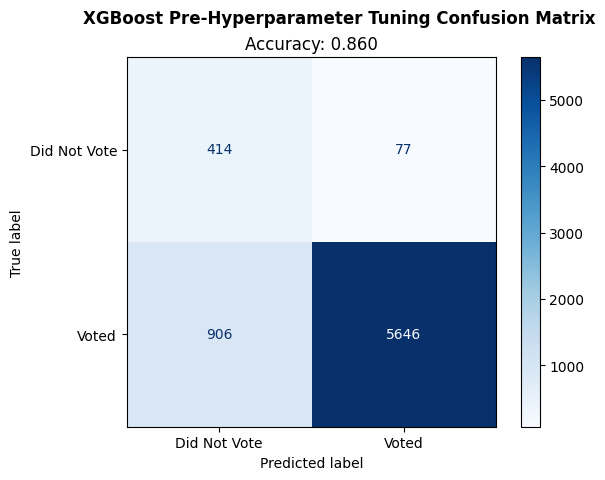

In [151]:
# Implementing XGBoost, initial demo
xgb_model = xgb.XGBClassifier(n_estimators = 40,
                              max_depth = 5,
                              scale_pos_weight = 1.0)
xgb_model.fit(X_train, y_train)

# Printing Confusion Matrix
y_pred = xgb_model.predict(X_val)
confusion_matrix_ex(y_val, y_pred, ["Did Not Vote", "Voted"], "XGBoost Pre-Hyperparameter Tuning")

Naive XGBoost Accuracy: 0.860428794547778
Naive XGBoost ROC-AUC: 0.9233097463749195

Classification Report:
               precision    recall  f1-score   support

         0.0       0.31      0.84      0.46       491
         1.0       0.99      0.86      0.92      6552

    accuracy                           0.86      7043
   macro avg       0.65      0.85      0.69      7043
weighted avg       0.94      0.86      0.89      7043



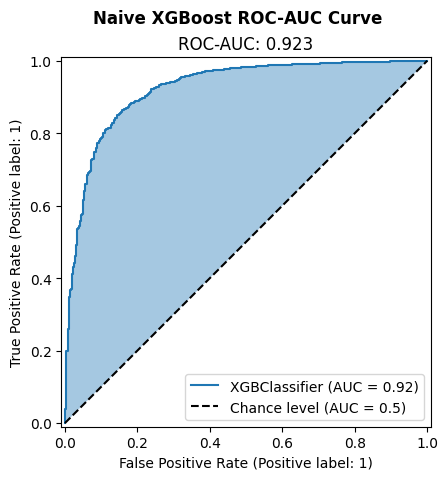

In [154]:
perf_output(xgb_model, X_val, y_val, "Naive XGBoost")

In [163]:
# Defining the XGB Objective space
def xgb_objective(trial):
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }
    
    # initializing the XGBoost model
    test_model = xgb.XGBClassifier(**param)
    test_model.fit(X_train, y_train)
    y_probs = test_model.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_probs)   # ROC-AUC as optimization metric
    return score

In [ ]:
xgb_study = optuna.create_study(study_name="xgboost_study", direction='maximize') 
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True, n_jobs=-1)
xgb_best_params = xgb_study.best_params   

[I 2026-03-11 23:54:30,709] A new study created in memory with name: xgboost_study


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-11 23:54:45,060] Trial 5 finished with value: 0.929442728577148 and parameters: {'max_depth': 3, 'learning_rate': 0.0616298411168081, 'n_estimators': 135, 'subsample': 0.681975983822712, 'colsample_bytree': 0.7072812865210956, 'min_child_weight': 4, 'gamma': 0.24772367031147657}. Best is trial 5 with value: 0.929442728577148.
[I 2026-03-11 23:54:53,666] Trial 31 finished with value: 0.9264349872802012 and parameters: {'max_depth': 3, 'learning_rate': 0.08925149504220715, 'n_estimators': 211, 'subsample': 0.5908127803506705, 'colsample_bytree': 0.891793195564864, 'min_child_weight': 7, 'gamma': 0.3255026656440446}. Best is trial 5 with value: 0.929442728577148.
[I 2026-03-11 23:54:53,844] Trial 23 finished with value: 0.9281486786578437 and parameters: {'max_depth': 9, 'learning_rate': 0.08801846720514268, 'n_estimators': 185, 'subsample': 0.5772316192694831, 'colsample_bytree': 0.7480370451009262, 'min_child_weight': 7, 'gamma': 4.314856939181645}. Best is trial 5 with value

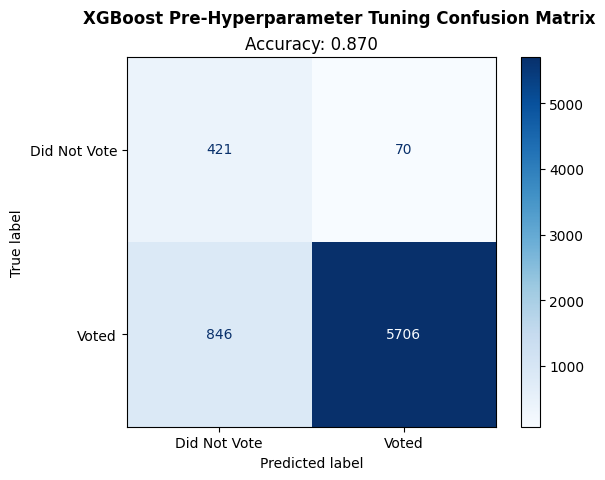

In [166]:
hyper_xgb = xgb.XGBClassifier(**xgb_best_params)
hyper_xgb.fit(X_train, y_train)

# Printing Confusion Matrix
y_pred = hyper_xgb.predict(X_val)
confusion_matrix_ex(y_val, y_pred, ["Did Not Vote", "Voted"], "XGBoost Pre-Hyperparameter Tuning")


Hyperopt. XGB Accuracy: 0.8699417861706659
Hyperopt. XGB ROC-AUC: 0.9313844251471544

Classification Report:
               precision    recall  f1-score   support

         0.0       0.33      0.86      0.48       491
         1.0       0.99      0.87      0.93      6552

    accuracy                           0.87      7043
   macro avg       0.66      0.86      0.70      7043
weighted avg       0.94      0.87      0.89      7043



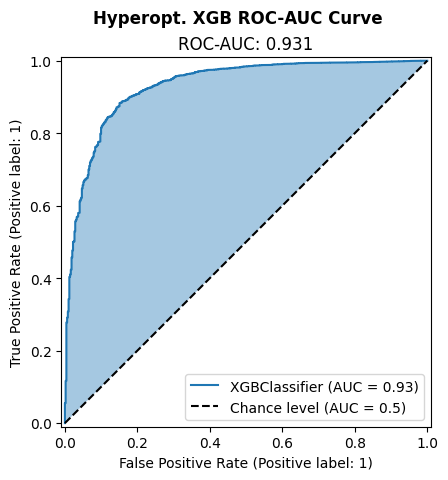

In [167]:
perf_output(hyper_xgb, X_val, y_val, "Hyperopt. XGB")

Hyperopt. XGB Accuracy: 0.8655402527332102
Hyperopt. XGB ROC-AUC: 0.9080307970485466

Classification Report:
               precision    recall  f1-score   support

         0.0       0.33      0.80      0.47       514
         1.0       0.98      0.87      0.92      6529

    accuracy                           0.87      7043
   macro avg       0.66      0.84      0.69      7043
weighted avg       0.93      0.87      0.89      7043



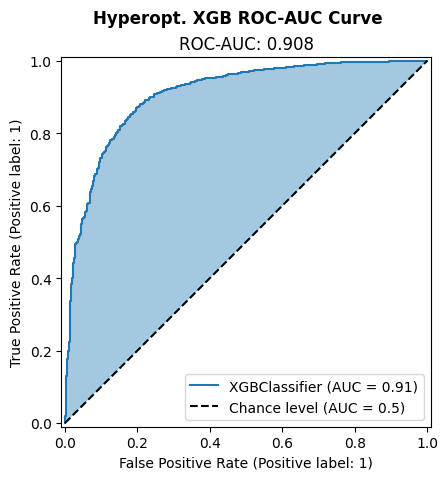

In [168]:
perf_output(hyper_xgb, X_test, y_test, "Hyperopt. XGB")